In [6]:
import numpy as np
from PIL import Image

In [56]:
img_albedo = Image.open('Earth_alb.png')
img_normal = Image.open('Earth_nrm.png')
img_mtl = Image.open('Earth_mtl.png')
img_mtl = img_mtl.resize((4096, 1024), Image.LANCZOS)
img_roughness = Image.open('Earth_rgh.png')

albedo = np.array(img_albedo)
normal = np.array(img_normal)
mtl = np.array(img_mtl)
roughness = np.array(img_roughness)

print(albedo.shape, albedo.max(), albedo.min())
print(normal.shape, normal.max(), normal.min())
print(mtl.shape, mtl.max(), mtl.min())
print(roughness.shape, roughness.max(), roughness.min())

(1024, 4096, 4) 255 0
(1024, 4096, 4) 255 0
(1024, 4096, 4) 255 0
(512, 2048, 4) 255 45


In [ ]:
m = mtl[..., :3].astype(np.float32)
m = m / 255.0
m = np.linalg.norm(m, axis=-1)
m = (m - m.min()) / (m.max() - m.min())
print(m.shape, m.max(), m.min())

(1024, 4096) 1.0 0.0


In [223]:
n = normal[..., :3].astype(np.float32)
n = n / 255.0 * 2.0 - 1.0

length = np.linalg.norm(n, axis=2, keepdims=True)
n /= np.maximum(length, 1e-6)

Nx = n[..., 0]
Ny = n[..., 1]
Nz = n[..., 2]

Ny = -Ny  # flip Y for image coordinates

eps = 1e-6
dzdx = Nx / (Nz + eps)
dzdy = Ny / (Nz + eps)

dzdx = gaussian_filter(dzdx, sigma=1.0)
dzdy = gaussian_filter(dzdy, sigma=1.0)

h = np.zeros_like(Nx)

import numpy as np
from numpy.fft import fft2, ifft2

# divergence of the gradient field
dx = np.zeros_like(dzdx)
dy = np.zeros_like(dzdy)

dx[:, :-1] = dzdx[:, :-1] - dzdx[:, 1:]
dy[:-1, :] = dzdy[:-1, :] - dzdy[1:, :]

f = dx + dy

# FFT Poisson solve
H, W = f.shape
ky = np.fft.fftfreq(H)[:, None]  # column vector
kx = np.fft.fftfreq(W)[None, :]

denom = (2 * np.cos(2*np.pi*kx) +
         2 * np.cos(2*np.pi*ky) - 4)

denom[0, 0] = 1  # avoid divide by zero

h = np.real(ifft2(fft2(f) / denom))
print(h.shape, h.max(), h.min())
h = (h - h.min()) / (h.max() - h.min())

(1024, 4096) 99.35884896246714 -21.41790648372583


In [208]:
from scipy.ndimage import distance_transform_edt

land = (m < 0.2)
dist_land = distance_transform_edt(land)
dist_sea = distance_transform_edt(~land)
dist_sea = (dist_sea - dist_sea.min()) / (dist_sea.max() - dist_sea.min())
decline = (1-dist_sea)**20
decline = gaussian_filter(decline, sigma=1.0)
decline = (decline - decline.min()) / (decline.max() - decline.min())
decline = decline**5
decline = (decline - decline.min()) / (decline.max() - decline.min())
h_2 = h * decline
h_2 = (h_2 - h_2.min()) / (h_2.max() - h_2.min())

In [227]:
Y, X = np.mgrid[0:h.shape[0], 0:h.shape[1]]
A = np.c_[X.ravel(), Y.ravel(), np.ones(X.size)]
C, *_ = np.linalg.lstsq(A, h.ravel(), rcond=None)

plane = (C[0]*X + C[1]*Y + C[2])

h = h-plane
h = (h - h.min()) / (h.max() - h.min())

(np.float64(-0.5), np.float64(4095.5), np.float64(1023.5), np.float64(-0.5))

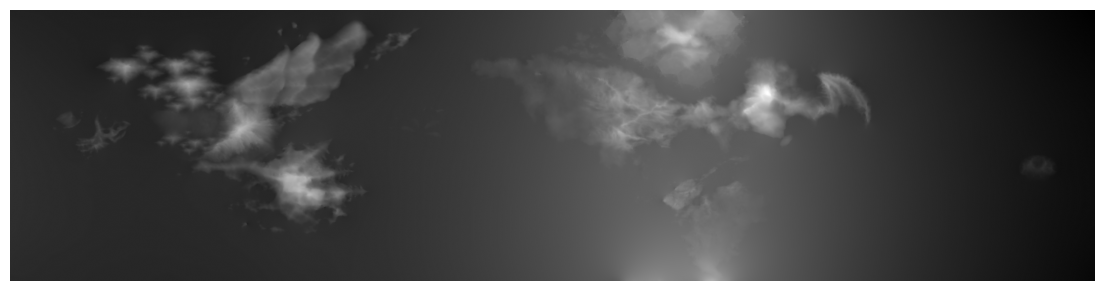

In [ ]:
dist_land = distance_transform_edt(land)
dist_sea = distance_transform_edt(~land)
signed_dist = dist_land - dist_sea
signed_dist = (signed_dist - signed_dist.min()) / (signed_dist.max() - signed_dist.min())

from matplotlib import pyplot as plt
plt.figure(figsize=(14, 14))
plt.imshow(h, cmap="gray")
#plt.colorbar()
plt.axis("off")

#Image.fromarray((h_2*65535).astype(np.uint16)).save('heightmap2.png')

In [128]:
print(np.unique(h_2)[1])

0.0037104424961787695
